In [7]:
import torch
import torch.nn as nn
from torchvision.models import resnet152, ResNet152_Weights

# 1. Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 2. Load pre-trained ResNet-152
weights = ResNet152_Weights.IMAGENET1K_V1
model = resnet152(weights=weights)

# 3. Freeze the backbone (disables gradient tracking)
for param in model.parameters():
    param.requires_grad = False

# 4. Replace the final layer for CIFAR-10 (10 classes instead of 1000)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 10)

model = model.to(device)

print(f"Model loaded! Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")

Using device: cuda
Model loaded! Trainable parameters: 20490


In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt

# 1. Define Transforms (Resize to 224x224 and normalize)
transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 2. Download and load CIFAR-10
print("Downloading datasets...")
train_dataset = torchvision.datasets.CIFAR10(root='../data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.CIFAR10(root='../data', train=False, download=True, transform=transform)

# Using a batch size of 128 to fully utilize the 8GB VRAM
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=0)

print(f"Train size: {len(train_dataset)} | Test size: {len(test_dataset)}")

Files already downloaded and verified
Files already downloaded and verified
Train size: 50000 | Test size: 10000


In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

# Initialize the gradient scaler for mixed precision
scaler = torch.cuda.amp.GradScaler()

epochs = 3
train_losses, val_accuracies = [], []

print("Starting Thermally-Safe Training...")
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]")
    for inputs, labels in pbar:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        
        # Enables autocasting for the forward pass (keeps the GPU cool)
        with torch.autocast(device_type="cuda"):
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
        # Scales the loss and calls backward
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        running_loss += loss.item()
        pbar.set_postfix({'loss': f"{loss.item():.4f}"})
        
    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)
    
    # Validation Phase
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in tqdm(test_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]"):
            inputs, labels = inputs.to(device), labels.to(device)
            # Use autocast for inference too to save heat
            with torch.autocast(device_type="cuda"):
                outputs = model(inputs)
                _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
    val_acc = 100 * correct / total
    val_accuracies.append(val_acc)
    print(f"Epoch {epoch+1} Summary -> Loss: {epoch_loss:.4f} | Val Accuracy: {val_acc:.2f}%\n")

C:\Users\mahad\AppData\Local\Temp\ipykernel_33600\1233436621.py:5: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


Starting Thermally-Safe Training...


Epoch 1/3 [Train]:  10%|▉         | 77/782 [00:17<02:38,  4.45it/s, loss=0.6822]


KeyboardInterrupt: 

In [ ]:
import types
from torchvision.models.resnet import Bottleneck

# 1. Load a fresh model and UNFREEZE it so we can measure gradients
broken_model = resnet152(weights=ResNet152_Weights.IMAGENET1K_V1)
broken_model.fc = nn.Linear(broken_model.fc.in_features, 10)
for param in broken_model.parameters():
    param.requires_grad = True # Fully unfrozen!

# 2. Define a sabotaged forward pass
def broken_forward(self, x):
    # We run the standard convolutions...
    out = self.conv1(x)
    out = self.bn1(out)
    out = self.relu(out)
    out = self.conv2(out)
    out = self.bn2(out)
    out = self.relu(out)
    out = self.conv3(out)
    out = self.bn3(out)
    
    # THE SABOTAGE: We completely remove this standard ResNet logic:
    # if self.downsample is not None:
    #     identity = self.downsample(x)
    # out += identity
    
    out = self.relu(out)
    return out

# 3. Inject our broken function into every Bottleneck layer in the model
bottleneck_count = 0
for name, module in broken_model.named_modules():
    if isinstance(module, Bottleneck):
        module.forward = types.MethodType(broken_forward, module)
        bottleneck_count += 1

broken_model = broken_model.to(device)
print(f"Sabotage complete! Severed skip connections in {bottleneck_count} Bottleneck layers.")

Sabotage complete! Severed skip connections in 50 Bottleneck layers.


In [ ]:
criterion = nn.CrossEntropyLoss()
broken_optimizer = optim.Adam(broken_model.parameters(), lr=0.001)

print("Testing gradient flow in FP32 (Standard Precision)...\n")
broken_model.train()

# We only need 5 batches, so FP32 is perfectly safe for thermals here
for i, (inputs, labels) in enumerate(train_loader):
    if i >= 5: 
        break
        
    inputs, labels = inputs.to(device), labels.to(device)
    broken_optimizer.zero_grad()
    
    # NO AUTOCAST - running in pure 32-bit to capture the tiny decimals
    outputs = broken_model(inputs)
    loss = criterion(outputs, labels)
    
    # Standard backward pass without the scaler
    loss.backward()
    
    # Extract gradient magnitudes (L2 Norm)
    last_layer_grad = broken_model.fc.weight.grad.norm().item()
    first_layer_grad = broken_model.conv1.weight.grad.norm().item()
    
    # Printing with 8 decimal places to see the micro-gradients
    print(f"Batch {i+1} | Last Layer Grad: {last_layer_grad:.4f} | First Layer Grad: {first_layer_grad:.8f}")
    
    broken_optimizer.step()

Testing gradient flow in FP32 (Standard Precision)...

Batch 1 | Last Layer Grad: 0.9703 | First Layer Grad: 12830.13769531
Batch 2 | Last Layer Grad: 2.1513 | First Layer Grad: 2331.38671875
Batch 3 | Last Layer Grad: 0.4330 | First Layer Grad: 13.45810413
Batch 4 | Last Layer Grad: 1.9260 | First Layer Grad: 126.67846680
Batch 5 | Last Layer Grad: 1.6262 | First Layer Grad: 14.48914719


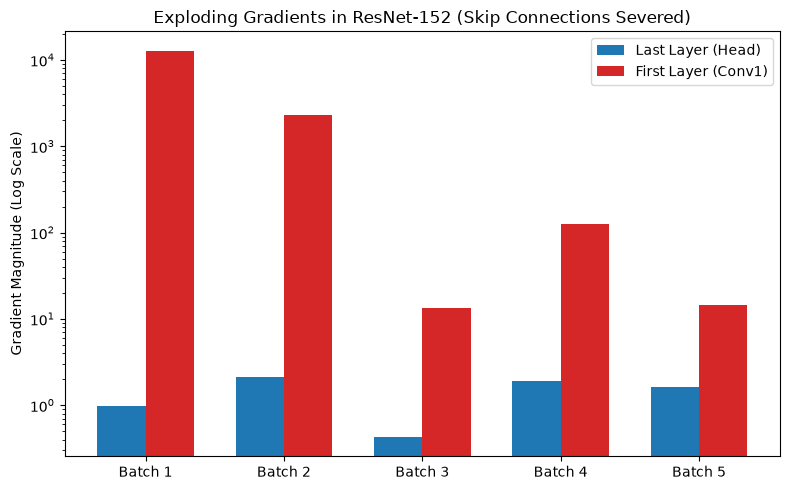

In [ ]:
import numpy as np

# Your FP32 diagnostic data
batches = ['Batch 1', 'Batch 2', 'Batch 3', 'Batch 4', 'Batch 5']
last_layer = [0.9703, 2.1513, 0.4330, 1.9260, 1.6262]
first_layer = [12830.1377, 2331.3867, 13.4581, 126.6784, 14.4891]

x = np.arange(len(batches))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
rects1 = ax.bar(x - width/2, last_layer, width, label='Last Layer (Head)', color='tab:blue')
rects2 = ax.bar(x + width/2, first_layer, width, label='First Layer (Conv1)', color='tab:red')

ax.set_ylabel('Gradient Magnitude (Log Scale)')
ax.set_title('Exploding Gradients in ResNet-152 (Skip Connections Severed)')
ax.set_xticks(x)
ax.set_xticklabels(batches)
ax.set_yscale('log') # Log scale allows us to see both scales simultaneously
ax.legend()

fig.tight_layout()
plt.savefig('../report/figures/task1_exploding_gradients.png', dpi=300)
plt.show()

Extracting features from network layers...
Extraction complete! Running t-SNE dimensionality reduction...


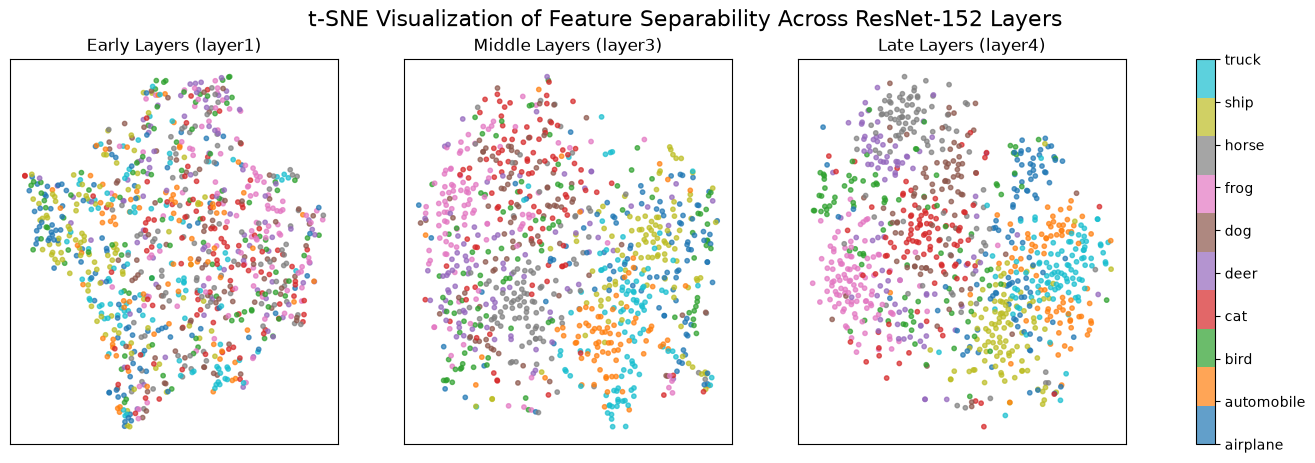

In [ ]:
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# 1. Setup storage and hooks
extracted_features = {'early': [], 'middle': [], 'late': [], 'labels': []}

def get_features(name):
    def hook(model, input, output):
        # Average pool the spatial dimensions (B, C, H, W) -> (B, C)
        pooled_output = output.mean(dim=[2, 3])
        extracted_features[name].append(pooled_output.detach().cpu().numpy())
    return hook

# Register the hooks to the original, healthy model
h1 = model.layer1.register_forward_hook(get_features('early'))
h2 = model.layer3.register_forward_hook(get_features('middle'))
h3 = model.layer4.register_forward_hook(get_features('late'))

# 2. Push a subset of images through the network
model.eval()
print("Extracting features from network layers...")
with torch.no_grad():
    for i, (inputs, labels) in enumerate(test_loader):
        if i >= 15: # ~1000 images is plenty for a clean t-SNE plot
            break
        inputs = inputs.to(device)
        model(inputs) # Forward pass triggers the hooks
        extracted_features['labels'].append(labels.numpy())

# Clean up the hooks so they don't slow down future code
h1.remove()
h2.remove()
h3.remove()

# Concatenate the lists into flat numpy arrays
for key in extracted_features:
    extracted_features[key] = np.concatenate(extracted_features[key])

print(f"Extraction complete! Running t-SNE dimensionality reduction...")

# 3. Run t-SNE (This takes about 30-60 seconds to do the math)
tsne = TSNE(n_components=2, random_state=42)
projected_early = tsne.fit_transform(extracted_features['early'])
projected_middle = tsne.fit_transform(extracted_features['middle'])
projected_late = tsne.fit_transform(extracted_features['late'])

# 4. Plot the results
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
titles = ['Early Layers (layer1)', 'Middle Layers (layer3)', 'Late Layers (layer4)']
projections = [projected_early, projected_middle, projected_late]
labels = extracted_features['labels']

for ax, proj, title in zip(axes, projections, titles):
    scatter = ax.scatter(proj[:, 0], proj[:, 1], c=labels, cmap='tab10', alpha=0.7, s=10)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])

# Add a single legend for the classes
cbar = plt.colorbar(scatter, ax=axes.ravel().tolist(), ticks=range(10))
cbar.set_ticklabels(['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck'])

fig.suptitle('t-SNE Visualization of Feature Separability Across ResNet-152 Layers', fontsize=16)
plt.savefig('../report/figures/task1_tsne_features.png', dpi=300)
plt.show()

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.models import resnet152, ResNet152_Weights
from tqdm import tqdm
import time

# Helper function for safe, thermally-efficient training
def train_config(model, name, epochs=3):
    print(f"\n--- Starting: {name} ---")
    criterion = nn.CrossEntropyLoss()
    # We pass ALL model parameters to the optimizer because nothing is frozen
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    scaler = torch.amp.GradScaler('cuda')
    
    start_time = time.time()
    for epoch in range(epochs):
        model.train()
        
        # Train pass
        for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}", leave=False):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            
            with torch.autocast(device_type="cuda"):
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            
        # Validation pass
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                with torch.autocast(device_type="cuda"):
                    outputs = model(inputs)
                    _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                
        val_acc = 100 * correct / total
        print(f"Epoch {epoch+1} Val Acc: {val_acc:.2f}%")
        
    time_taken = (time.time() - start_time) / 60
    print(f"Completed {name} in {time_taken:.2f} mins | Final Acc: {val_acc:.2f}%")
    return val_acc

# ==========================================
# Config 2: Pretrained + Full Backbone (Unfrozen)
# ==========================================
model_full = resnet152(weights=ResNet152_Weights.IMAGENET1K_V1)
model_full.fc = nn.Linear(model_full.fc.in_features, 10)
model_full = model_full.to(device)
# Note: By default, requires_grad is True for all parameters, so it is fully unfrozen!

# ==========================================
# Config 3: Random Initialization (Scratch)
# ==========================================
model_scratch = resnet152(weights=None) # weights=None means Random Init!
model_scratch.fc = nn.Linear(model_scratch.fc.in_features, 10)
model_scratch = model_scratch.to(device)

# Run the comparisons
acc_full = train_config(model_full, "Pretrained Weights + Full Backbone")
acc_scratch = train_config(model_scratch, "Random Init + Full Backbone (Scratch)")

print(f"\n================ FINAL COMPARISON ================")
print(f"1. Pretrained + Head Only (Baseline): ~84.47% (from earlier)")
print(f"2. Pretrained + Full Backbone: {acc_full:.2f}%")
print(f"3. Random Init + Full Backbone: {acc_scratch:.2f}%")


--- Starting: Pretrained Weights + Full Backbone ---


Epoch 1 Val Acc: 78.48%


Epoch 2 Val Acc: 81.13%


Epoch 3 Val Acc: 81.63%
Completed Pretrained Weights + Full Backbone in 21.01 mins | Final Acc: 81.63%

--- Starting: Random Init + Full Backbone (Scratch) ---


Epoch 1 Val Acc: 48.00%


Epoch 2 Val Acc: 40.87%


Epoch 3 Val Acc: 63.66%
Completed Random Init + Full Backbone (Scratch) in 19.97 mins | Final Acc: 63.66%

================ FINAL COMPARISON ================
1. Pretrained + Head Only (Baseline): ~84.47% (from earlier)
2. Pretrained + Full Backbone: 81.63%
3. Random Init + Full Backbone: 63.66%
